# Lab 6: Visualization of multi dimensional data

1. Dataset Introduction & Load

In [1]:
import pandas as pd
df = pd.read_csv('Datasets/WineQT.csv') 
print(df.shape)
print(df.head())

(1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1

2. Parallel Coordinates Plot

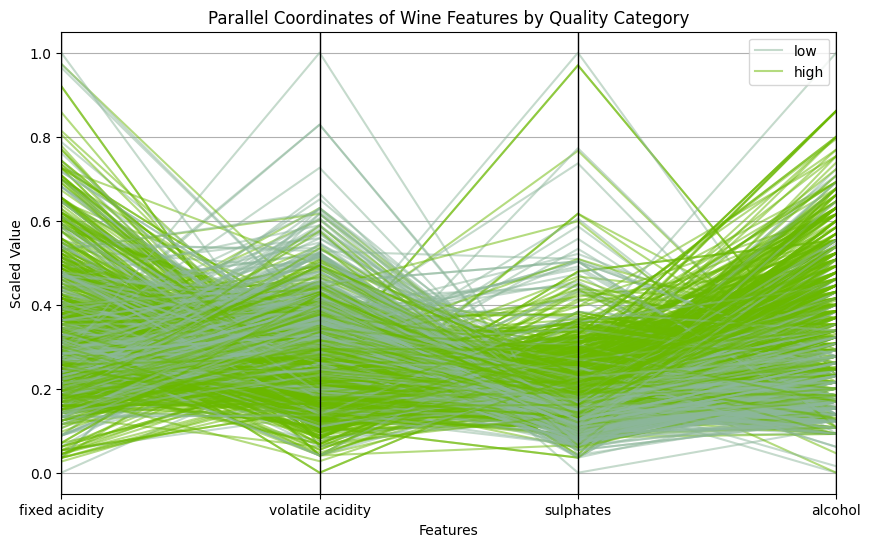

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

# Select features and apply scaling
features = ['fixed acidity', 'volatile acidity', 'sulphates', 'alcohol']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

# Create quality category
df_scaled['quality_cat'] = df_scaled['quality'].apply(lambda x: 'low' if x <= 5 else 'high')

# Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df_scaled[['quality_cat'] + features], 'quality_cat', alpha=0.5)
plt.title('Parallel Coordinates of Wine Features by Quality Category')
plt.xlabel('Features')
plt.ylabel('Scaled Value')
plt.show()


3. Scattered Matrix

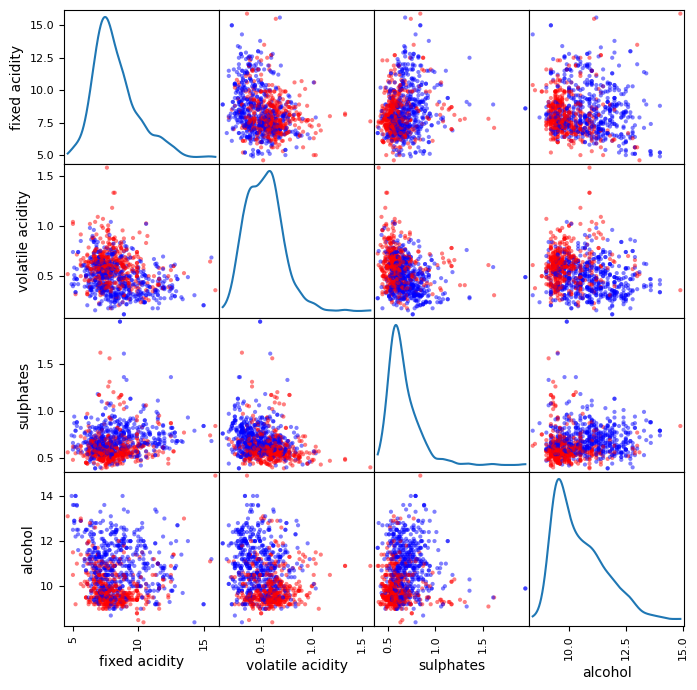

In [4]:
from pandas.plotting import scatter_matrix
sample = df.sample(1000)
scatter_matrix(sample[features], figsize=(8,8), diagonal='kde', c=sample['quality_cat'].map({'low':'red','high':'blue'}), alpha=0.5)
plt.show()


4. Seaborn Pairplot

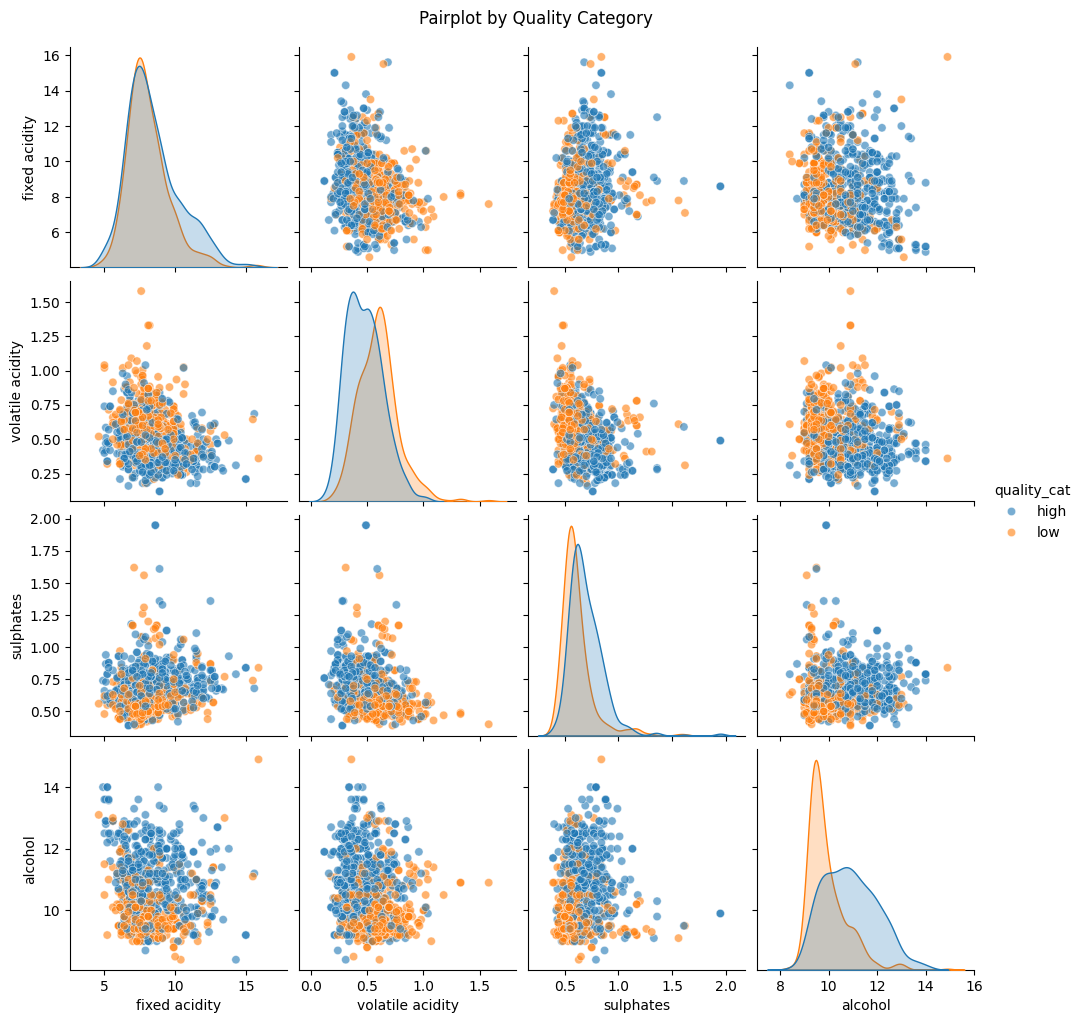

In [5]:
import seaborn as sns
sns.pairplot(sample, vars=features, hue='quality_cat', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot by Quality Category', y=1.02)
plt.show()


Observation: Note clusters or outlier wines (e.g high alcohol but low acidity).

5. PCA Projection (2 Components)

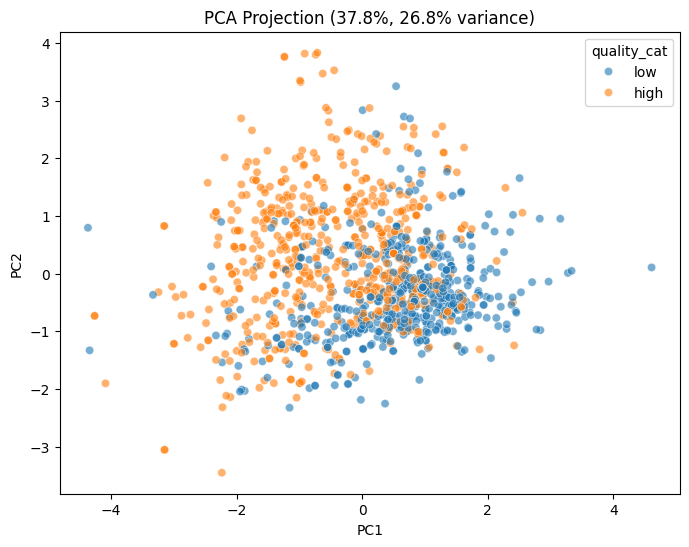

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df[features])
pca = PCA(n_components=2).fit(X)
proj = pca.transform(X)
explained = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=df['quality_cat'], alpha=0.6)
plt.title(f'PCA Projection ({explained[0]:.1f}%, {explained[1]:.1f}% variance)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


6. t‑SNE Embedding

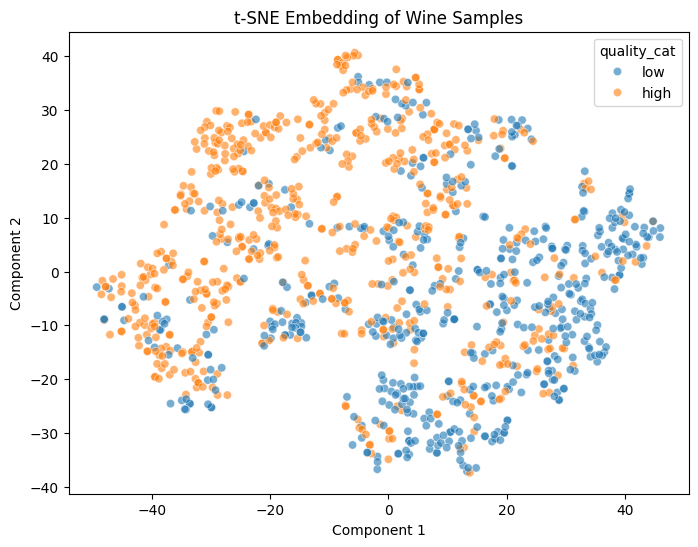

In [7]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
emb = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=df['quality_cat'], alpha=0.6)
plt.title('t‑SNE Embedding of Wine Samples')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()
